In [2]:
import matplotlib.pyplot as plt
import glob
import os
import cv2

In [3]:
predictions = sorted(glob.glob('/Users/cmbreen/code/snowpoles/models/trained_alaska_cnn/predictions/*.png'))
predictions = sorted(glob.glob('/Users/cmbreen/code/snowpoles/models/trained_alaska_cnn_onepole/predictions/*.png'))

In [4]:
predictions[:5]

['/Users/cmbreen/code/snowpoles/models/trained_alaska_cnn_onepole/predictions/pred_BC1TLDA_WSCT5052.png',
 '/Users/cmbreen/code/snowpoles/models/trained_alaska_cnn_onepole/predictions/pred_BC1TLDA_WSCT5296.png',
 '/Users/cmbreen/code/snowpoles/models/trained_alaska_cnn_onepole/predictions/pred_BC1TLDA_WSCT5326.png',
 '/Users/cmbreen/code/snowpoles/models/trained_alaska_cnn_onepole/predictions/pred_BC1TLDA_WSCT5346.png',
 '/Users/cmbreen/code/snowpoles/models/trained_alaska_cnn_onepole/predictions/pred_BC1TLDA_WSCT5360.png']

In [5]:
# Extract camera IDs and group images by camera
camera_images = {}
for path in predictions:
    filename = os.path.basename(path)
    # Extract camera ID (assuming format: pred_CAMERAID_IMAGEID.png)
    parts = filename.split('_')
    if len(parts) >= 3:
        camera_id = parts[1]  # BC11TLSB, BC13TLWA, etc.
        # Initialize list if camera not seen before
        if camera_id not in camera_images:
            camera_images[camera_id] = []
        
        # Append this path to the list for this camera
        camera_images[camera_id].append(path)

# Sort camera IDs for consistent ordering
sorted_cameras = sorted(camera_images.keys())

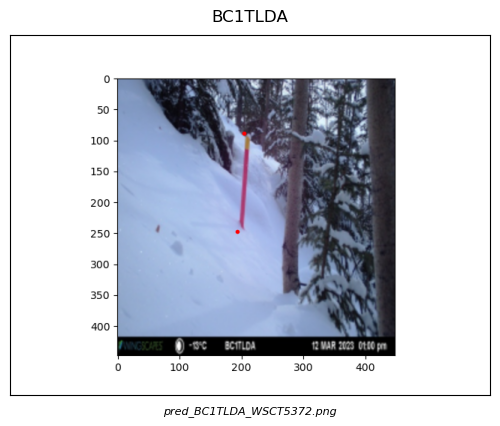


Summary:
Total cameras: 1
BC1TLDA: 10 images


In [6]:

# Create 5x3 subplot grid
fig, axes = plt.subplots(5, 3, figsize=(15, 25))
axes_flat = axes.flatten()

# Plot middle image for each camera
for i, camera_id in enumerate(sorted_cameras):
    if i < len(axes_flat):  # Make sure we don't exceed grid size
        ax = axes_flat[i]
        
        # Get images for this camera and sort them
        camera_image_list = sorted(camera_images[camera_id])
        
        if len(camera_image_list) > 0:
            # Get middle image
            middle_index = len(camera_image_list) // 2
            middle_image_path = camera_image_list[middle_index]
            
            try:
                # Load and display the image
                img = cv2.imread(middle_image_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ax.imshow(img)
                ax.set_title(f'{camera_id}', fontsize=12, pad=10)
                
                # Add filename as subtitle
                filename = os.path.basename(middle_image_path)
                ax.text(0.5, -0.05, filename, transform=ax.transAxes, 
                       ha='center', fontsize=8, style='italic')
                
            except Exception as e:
                ax.text(0.5, 0.5, f'Error loading\n{camera_id}', 
                       transform=ax.transAxes, ha='center', va='center')
                print(f"Error loading image for {camera_id}: {e}")
        else:
            ax.text(0.5, 0.5, f'No images\nfor {camera_id}', 
                   transform=ax.transAxes, ha='center', va='center')
        
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect('equal')

# Hide unused subplots
for i in range(len(sorted_cameras), len(axes_flat)):
    axes_flat[i].set_visible(False)

plt.tight_layout()
plt.show()

# Print summary
print(f"\nSummary:")
print(f"Total cameras: {len(sorted_cameras)}")
for camera_id in sorted_cameras:
    print(f"{camera_id}: {len(camera_images[camera_id])} images")